## Unsupervised Learning

* Daten laden
* Daten explorieren
* Daten visualisieren 
* Daten vorbereiten und Unsupervised Learning

In [1]:
from pandas import read_csv
from matplotlib import pyplot as plt 
from seaborn import pairplot, heatmap, clustermap
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy .cluster import hierarchy

## Daten laden

In [2]:
df = read_csv("../data/titanic.csv")

## Daten explorieren 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.head(2) # und df.tail(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


## Daten visualisieren

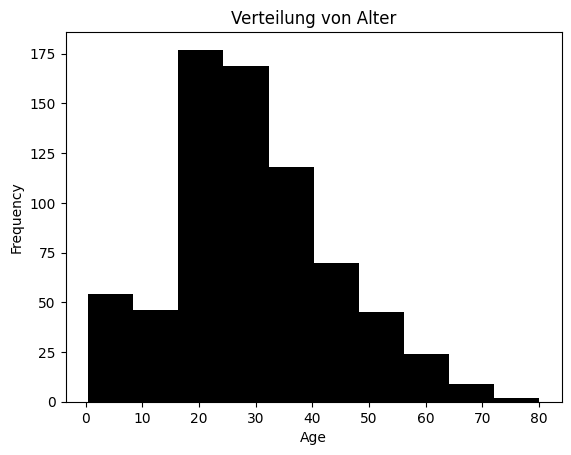

In [6]:
df["Age"].plot(kind="hist",color="k")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Verteilung von Alter")
plt.savefig("../output/age_histogram.png")

### nachträglich pip installieren 

```python
!pip install -r ../requirements.txt    # wenn aus file installiert 
!pip install wonderboy # wenn nur einzelne Bibiliothek 
```


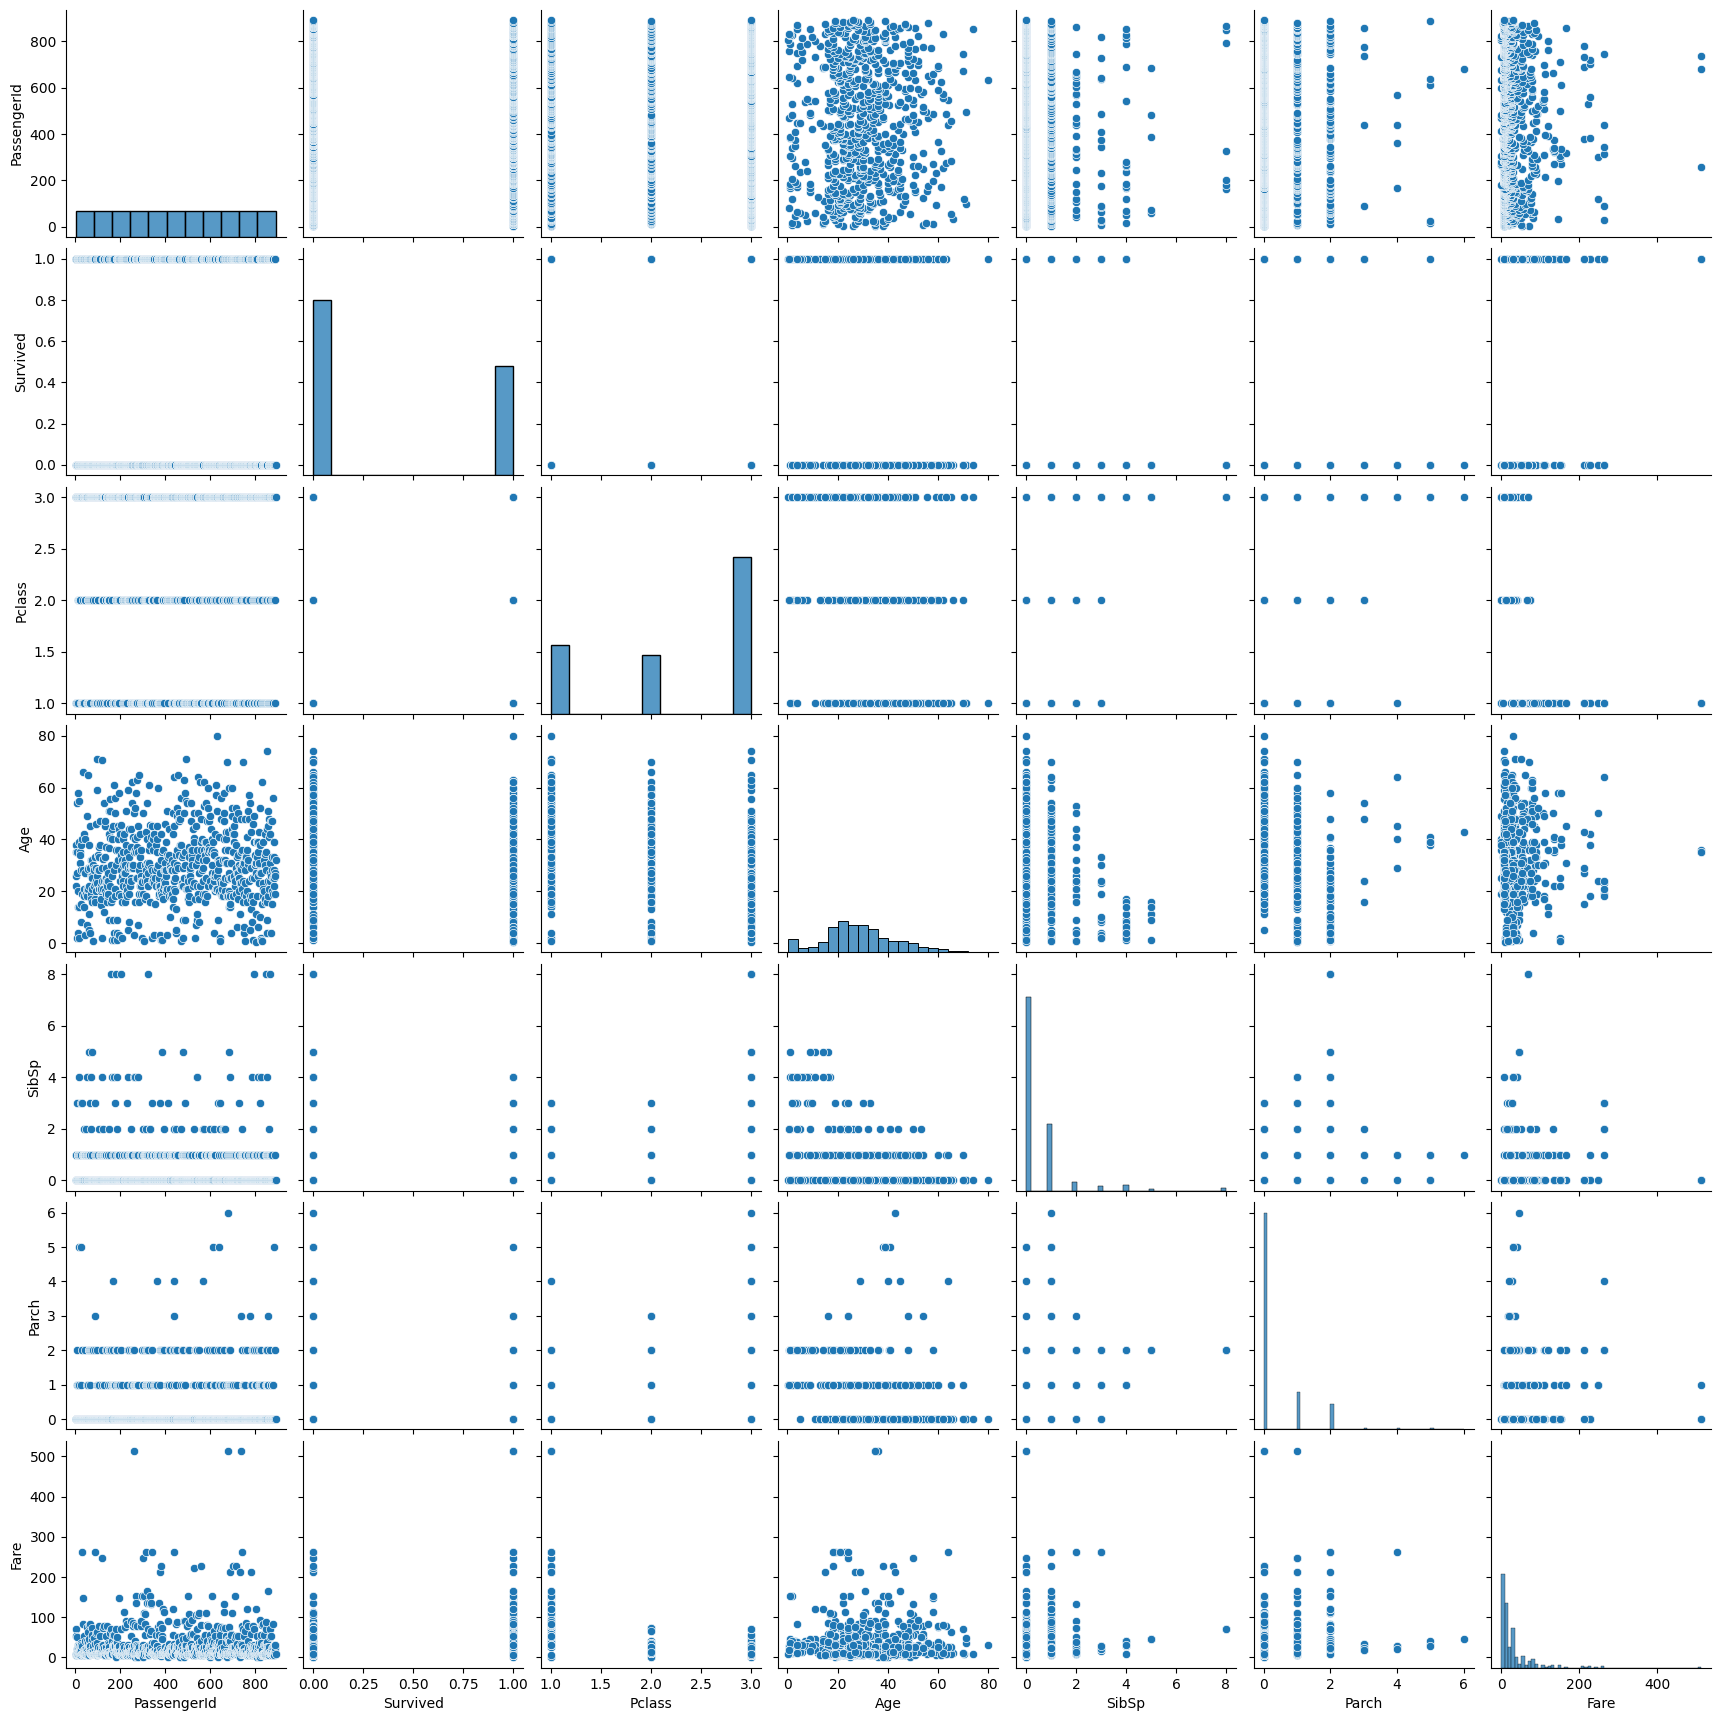

In [7]:
pairplot(df)

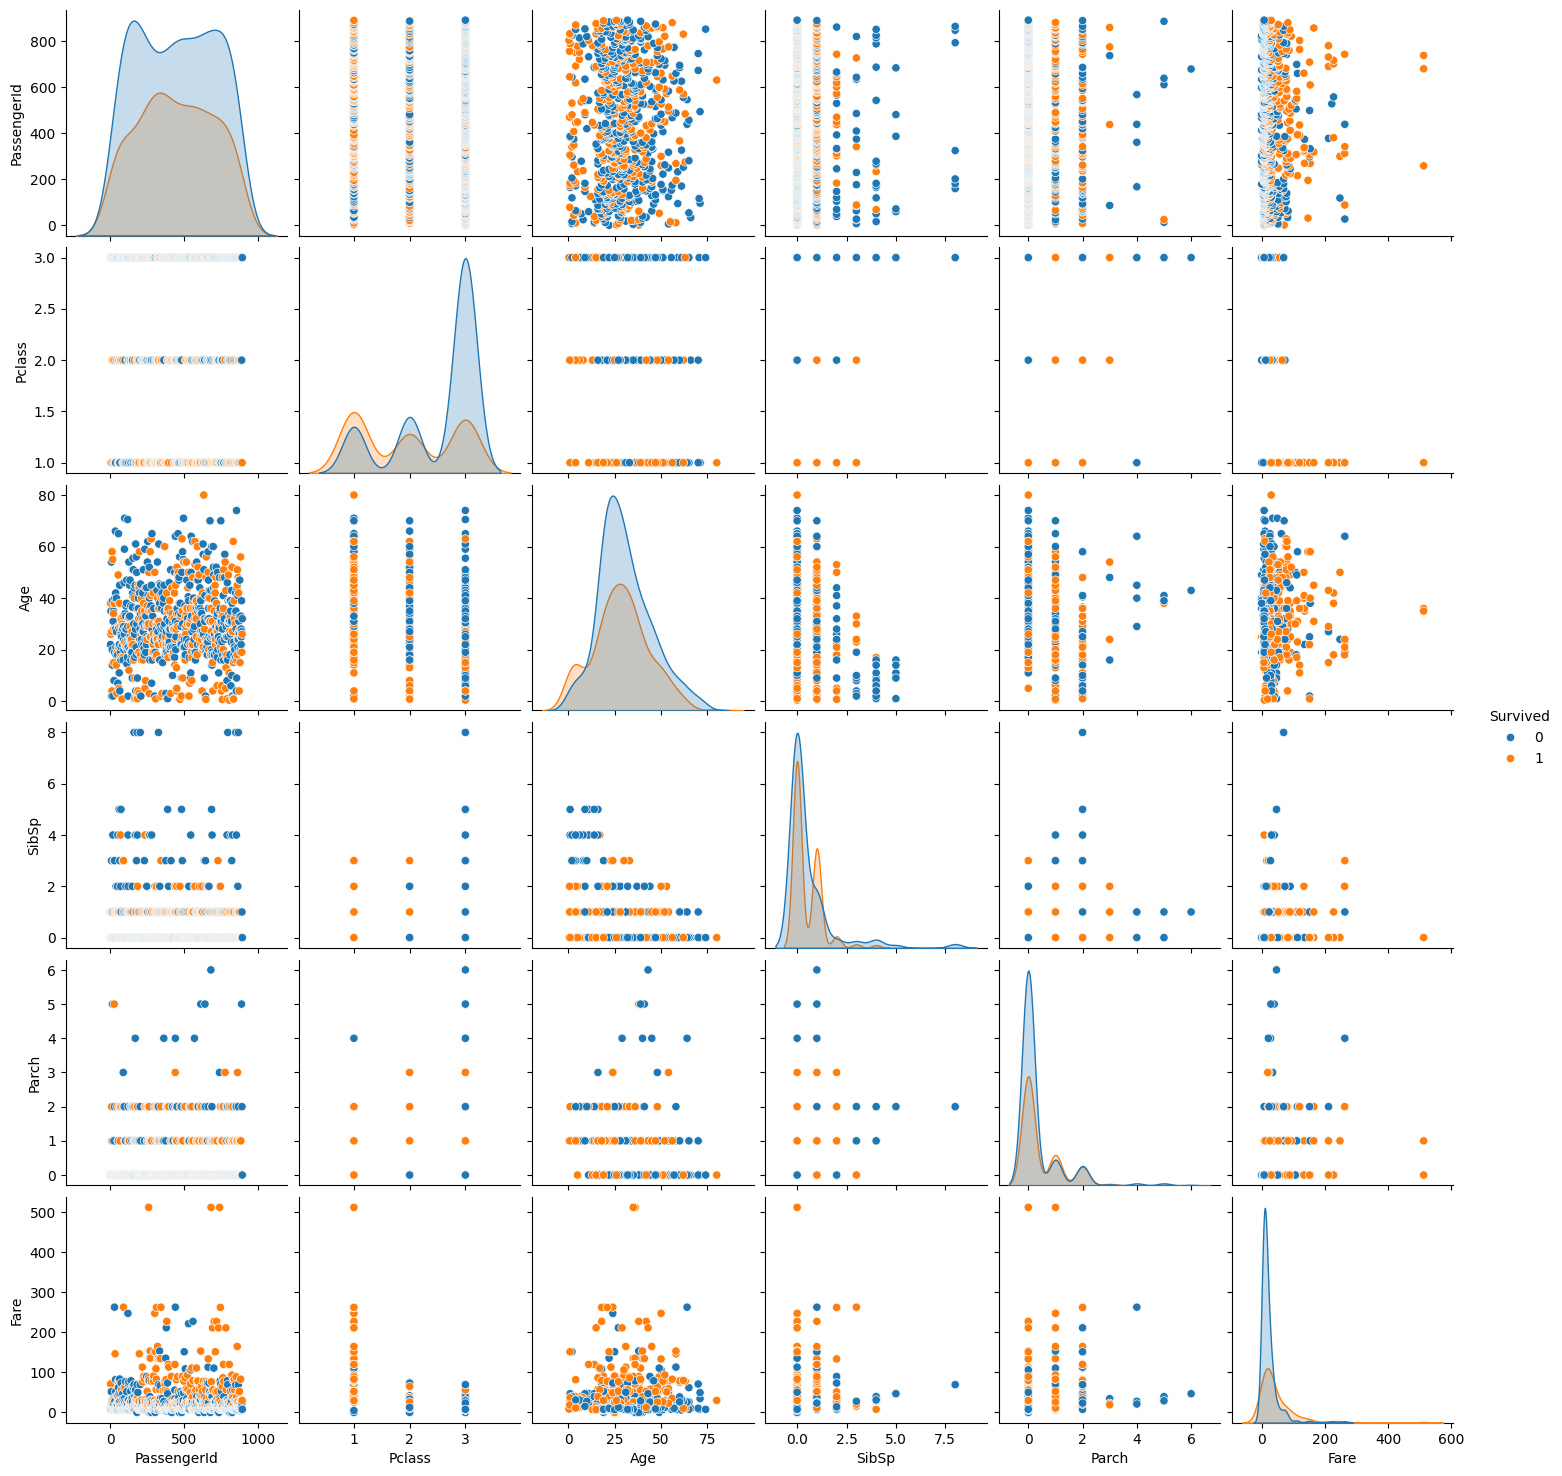

In [8]:
pairplot(df, hue="Survived")

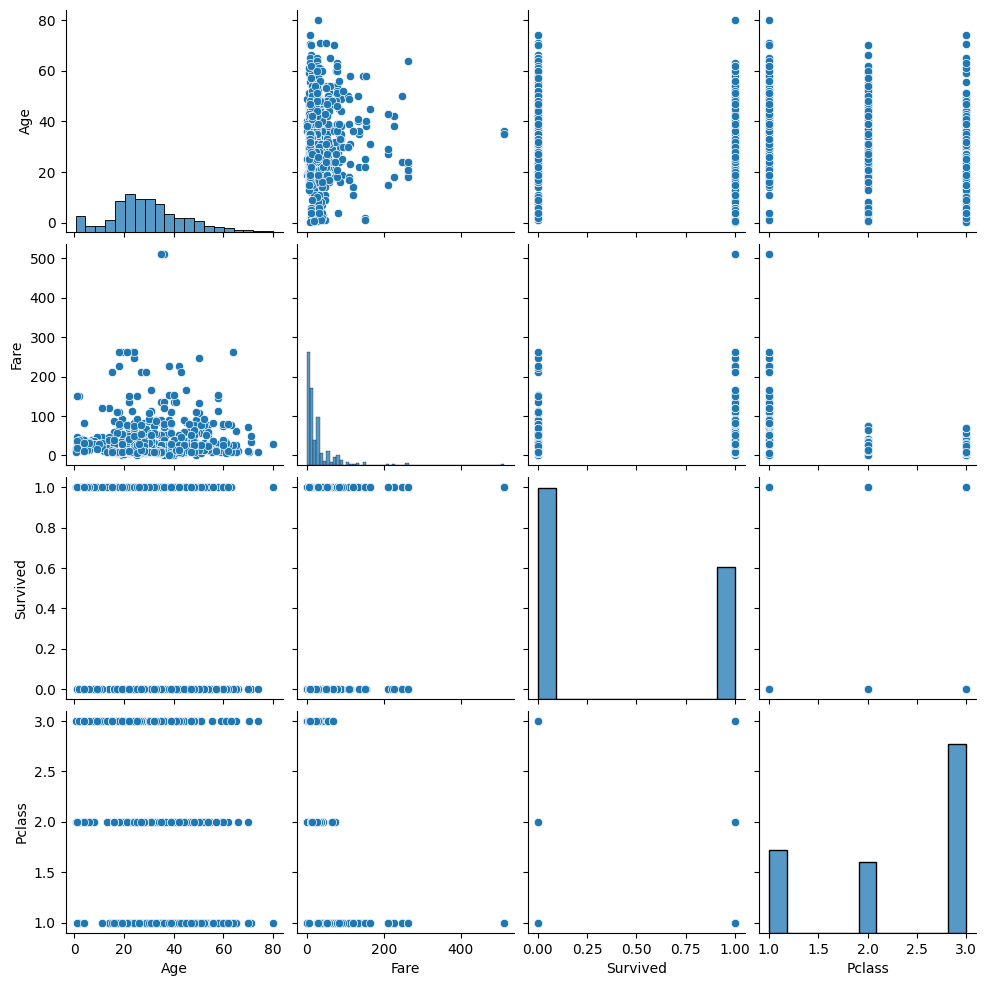

In [9]:
pairplot(df[["Age","Fare","Survived","Pclass"]])

In [10]:
df[["Age","Fare"]].corr()

,Age,Fare
Age,1.000000,0.096067
Fare,0.096067,1.000000


In [11]:
df.select_dtypes(include="number").corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


Fare und Survived haben eine positive Korrelation (0.257) → Passagiere mit höherem Ticketpreis hatten etwas bessere Überlebenschancen.
Pclass und Survived haben eine negative Korrelation (-0.338) → Passagiere der höheren Klassen (1. Klasse) überlebten häufiger als jene der 3. Klasse.

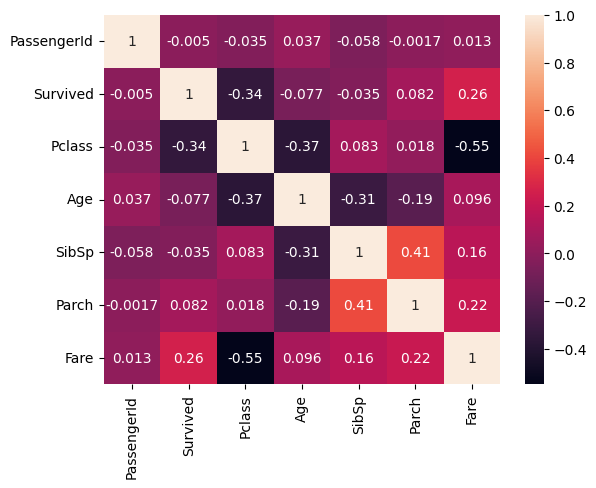

In [12]:
heatmap(
    df.select_dtypes(include="number").corr(),
    #cmap= "Greys",
    annot=True
)
plt.savefig("../output/heatmap.png")

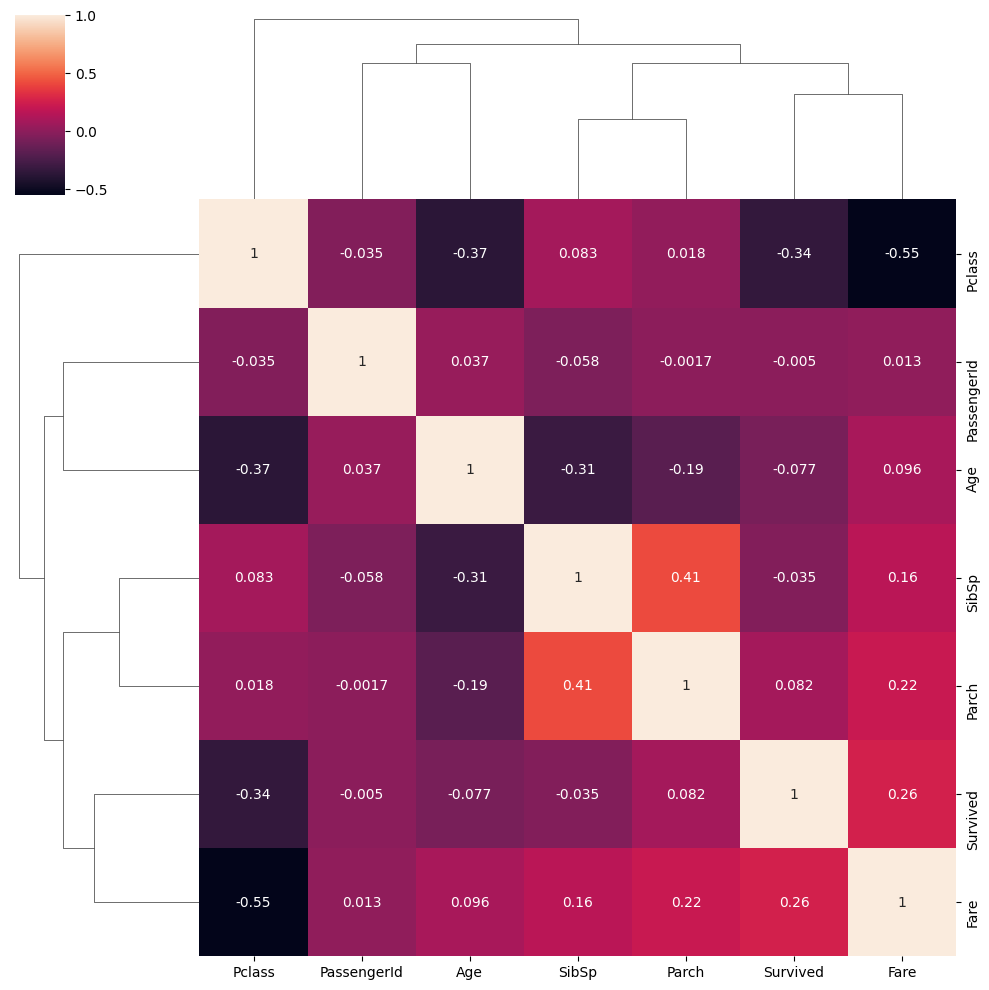

In [13]:
clustermap(
    df.select_dtypes(include="number").corr(),
    #cmap= "Greys",
    annot=True
)
plt.savefig("../output/clustermap.png")

## Daten vorbereiten für ML (Machine Learning)

* Nicht-nummerische in Nummerische Daten umwendeln 
* Fehlende Werte auffüllen

In [14]:
list(df.columns) 

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [15]:
target_colum = 'Survived' 
used_colums = [
    #'Survived',
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
]

In [16]:
df = df[used_colums].copy()

In [17]:
df[["Sex"]].value_counts()

Sex   
male      577
female    314
Name: count, dtype: int64

In [18]:
# nur einaml ausführen sonst überschireben und zu NaN oder eben 0:0 und 1:1 hinzufügen 
mapping_dictionary = {

    "female": 1,
    "male": 0,
    0:0,
    1:1

}
# df["Neu"] = df["Sex"].map(mapping_dictionary)     # neue Spalte anlegen mit neuen Werten
df["Sex"] = df["Sex"].map(mapping_dictionary)       # alte Spalte "Sex" überschreiben


In [19]:
df

,Pclass,Sex,Age,SibSp,Parch
0,3,0,22.0,1,0
1,1,1,38.0,1,0
2,3,1,26.0,0,0
3,1,1,35.0,1,0
4,3,0,35.0,0,0
...,...,...,...,...,...
886,2,0,27.0,0,0
887,1,1,19.0,0,0
888,3,1,NaN,1,2
889,1,0,26.0,0,0


In [20]:
df

,Pclass,Sex,Age,SibSp,Parch
0,3,0,22.0,1,0
1,1,1,38.0,1,0
2,3,1,26.0,0,0
3,1,1,35.0,1,0
4,3,0,35.0,0,0
...,...,...,...,...,...
886,2,0,27.0,0,0
887,1,1,19.0,0,0
888,3,1,NaN,1,2
889,1,0,26.0,0,0


In [21]:
# df["Age"].fillna(-999, inplace=True)
# df["Age"].fillna(df["Age"].median(), implace = True)
df.dropna(inplace=True)

## Unsupervised Machine Learning 

In [22]:
# Hierachisches Clustern mit Scipy
Z = hierarchy.linkage(df, method="ward")   # baut distance Matrix

{'icoord': [[25.0, 25.0, 35.0, 35.0],
  [55.0, 55.0, 65.0, 65.0],
  [45.0, 45.0, 60.0, 60.0],
  [30.0, 30.0, 52.5, 52.5],
  [15.0, 15.0, 41.25, 41.25],
  [5.0, 5.0, 28.125, 28.125],
  [85.0, 85.0, 95.0, 95.0],
  [75.0, 75.0, 90.0, 90.0],
  [115.0, 115.0, 125.0, 125.0],
  [105.0, 105.0, 120.0, 120.0],
  [82.5, 82.5, 112.5, 112.5],
  [165.0, 165.0, 175.0, 175.0],
  [155.0, 155.0, 170.0, 170.0],
  [145.0, 145.0, 162.5, 162.5],
  [135.0, 135.0, 153.75, 153.75],
  [185.0, 185.0, 195.0, 195.0],
  [144.375, 144.375, 190.0, 190.0],
  [97.5, 97.5, 167.1875, 167.1875],
  [225.0, 225.0, 235.0, 235.0],
  [215.0, 215.0, 230.0, 230.0],
  [245.0, 245.0, 255.0, 255.0],
  [222.5, 222.5, 250.0, 250.0],
  [205.0, 205.0, 236.25, 236.25],
  [132.34375, 132.34375, 220.625, 220.625],
  [265.0, 265.0, 275.0, 275.0],
  [295.0, 295.0, 305.0, 305.0],
  [335.0, 335.0, 345.0, 345.0],
  [325.0, 325.0, 340.0, 340.0],
  [315.0, 315.0, 332.5, 332.5],
  [300.0, 300.0, 323.75, 323.75],
  [285.0, 285.0, 311.875, 311.875]

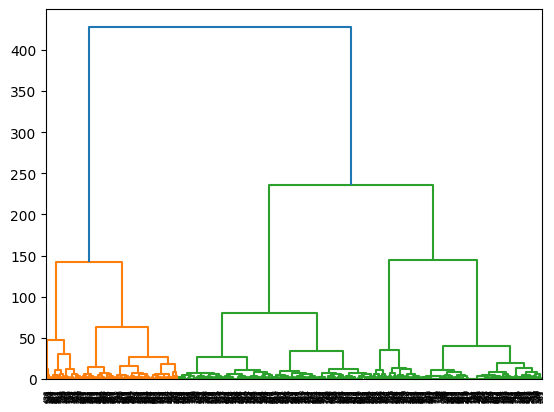

In [23]:
hierarchy.dendrogram(Z)

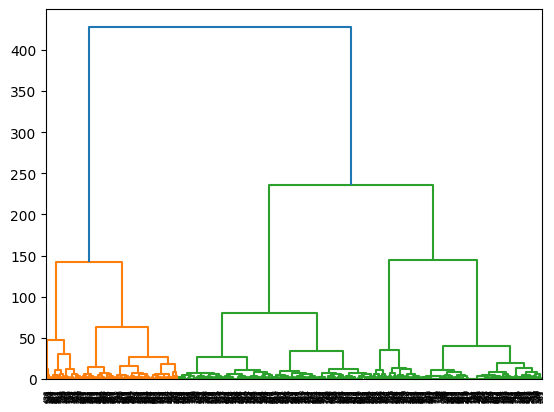

In [24]:
hierarchy.dendrogram(Z)
plt.show()

In [25]:
# Hierachisches Clustering mit SkLearn 
hierarchical_engine = AgglomerativeClustering()
hc_result = hierarchical_engine.fit_predict(df)

In [26]:
# kmeans Clustering mit SkLearn 
kmeans_engine = KMeans(n_clusters=2)
km_result = kmeans_engine.fit_predict(df)

In [27]:
df["hierachical_clustering_result"] = hc_result
df["k-means result"] = km_result

In [28]:
df

,Pclass,Sex,Age,SibSp,Parch,hierachical_clustering_result,k-means result
0,3,0,22.0,1,0,0,1
1,1,1,38.0,1,0,1,0
2,3,1,26.0,0,0,0,1
3,1,1,35.0,1,0,0,0
4,3,0,35.0,0,0,0,0
...,...,...,...,...,...,...,...
885,3,1,39.0,0,5,1,0
886,2,0,27.0,0,0,0,1
887,1,1,19.0,0,0,0,1
889,1,0,26.0,0,0,0,1


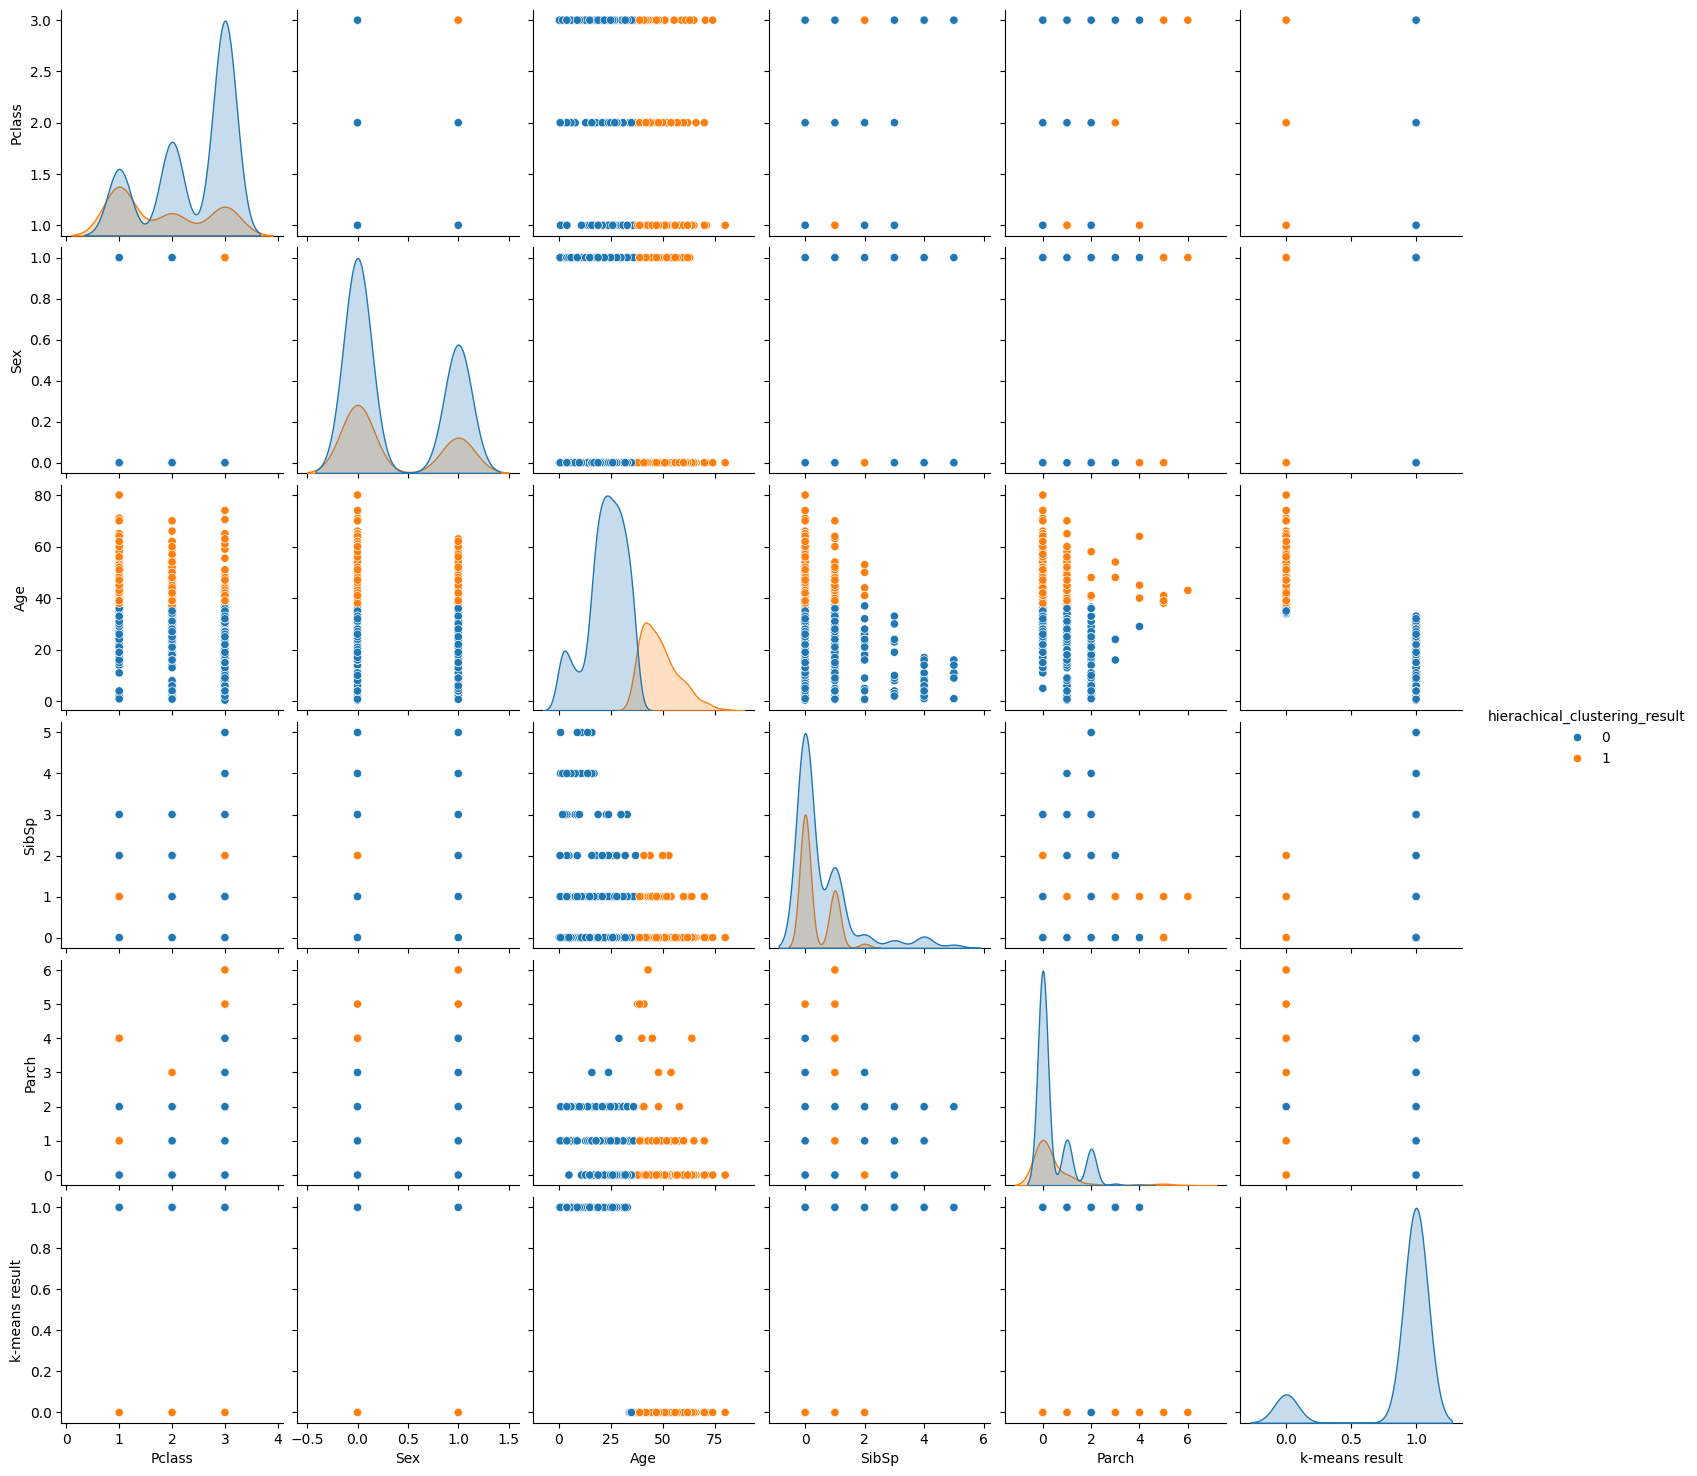

In [29]:
pairplot(df, hue="hierachical_clustering_result")